<a href="https://colab.research.google.com/github/yusuf-codes10/touir-youcef-abderahim-ml-automal-homework/blob/main/machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning TP Project | Touir Youcef Abderahim

## 1- installing and setting up the datasets from Kaggle

In [2]:
# STEP 1 — Set Kaggle credentials
import os
from getpass import getpass

os.environ['KAGGLE_USERNAME'] = input("Enter Kaggle username: ")
os.environ['KAGGLE_API_TOKEN'] = getpass("Enter Kaggle API key: ")

Enter Kaggle username: youcefcopy
Enter Kaggle API key: ··········


In [3]:
# STEP 2 — Install Kaggle & download datasets
!pip install kaggle

In [4]:
# STEP 3 — Download datasets
!kaggle datasets download -d vjchoudhary7/customer-segmentation-tutorial-in-python
!kaggle datasets download -d mlg-ulb/creditcardfraud

Dataset URL: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python
License(s): other
customer-segmentation-tutorial-in-python.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
creditcardfraud.zip: Skipping, found more recently modified local copy (use --force to force download)


In [5]:
# STEP 4 — Unzip datasets
!unzip -q customer-segmentation-tutorial-in-python.zip
!unzip -q creditcardfraud.zip

## 2- Laoding the data

In [6]:
import pandas as pd

mall_df = pd.read_csv('Mall_Customers.csv')
fraud_df = pd.read_csv('creditcard.csv')

## 3- Projects

### Project 1 – Mall *Customers*

In [8]:
# 1. Load
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

mall_df = pd.read_csv('Mall_Customers.csv')
mall_df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [9]:
# 2. Shape, dtypes, null check
print("Shape:", mall_df.shape)
print("\nDtypes:\n", mall_df.dtypes)
print("\nNull values:\n", mall_df.isnull().sum())
print("\nPreview:\n", mall_df.head())

Shape: (200, 5)

Dtypes:
 CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

Null values:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Preview:
    CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


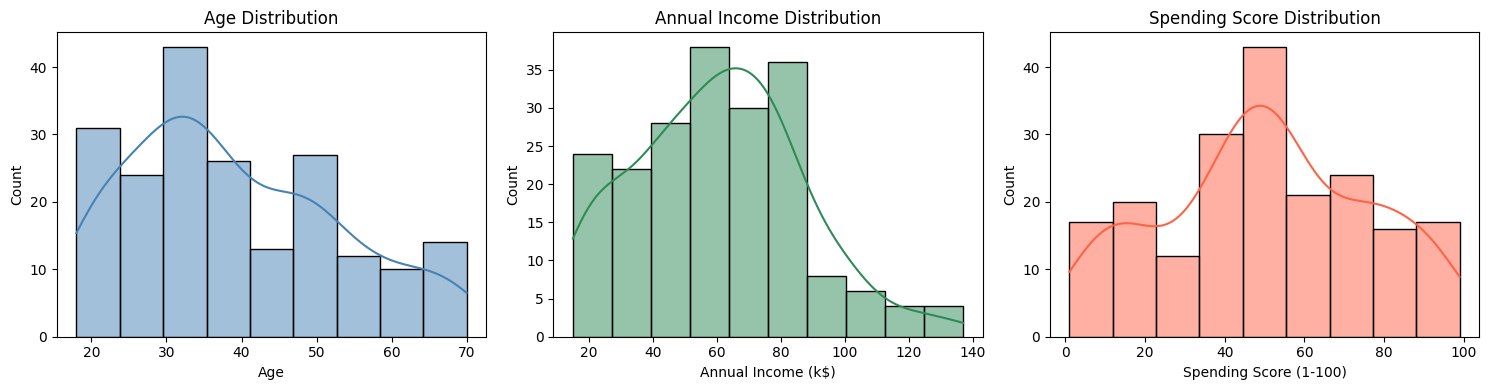

In [10]:
# 3. Distributions — Age, Income, Spending Score
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(mall_df['Age'], ax=axes[0], kde=True, color='steelblue')
axes[0].set_title('Age Distribution')

sns.histplot(mall_df['Annual Income (k$)'], ax=axes[1], kde=True, color='seagreen')
axes[1].set_title('Annual Income Distribution')

sns.histplot(mall_df['Spending Score (1-100)'], ax=axes[2], kde=True, color='tomato')
axes[2].set_title('Spending Score Distribution')

plt.tight_layout()
plt.show()

/tmp/ipykernel_532/768750220.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=mall_df, palette='Set2')


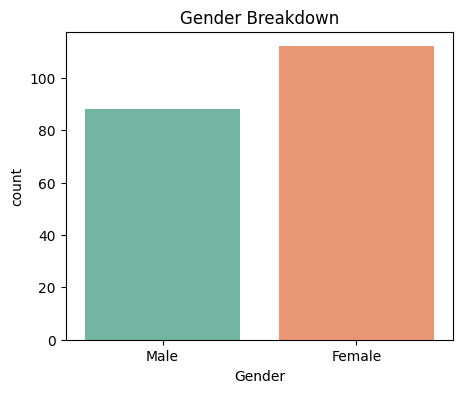

In [13]:
# 4. Gender breakdown
plt.figure(figsize=(5, 4))
sns.countplot(x='Gender', data=mall_df, palette='Set2')
plt.title('Gender Breakdown')
plt.show()

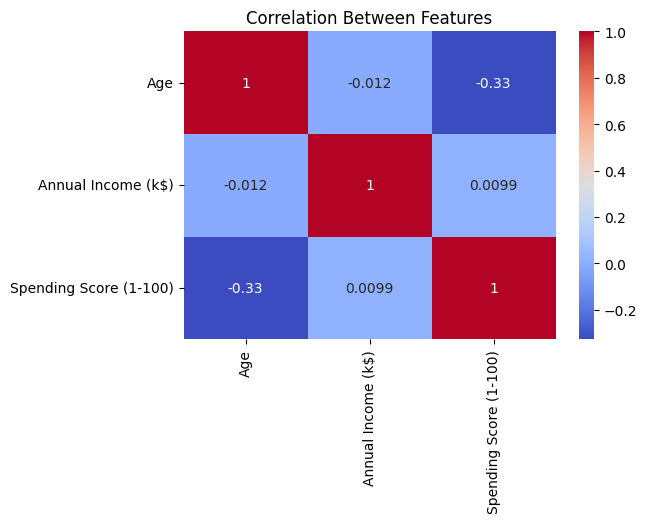

In [14]:
# 5. Correlation heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(mall_df.drop(columns=['CustomerID', 'Gender']).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Between Features')
plt.show()

**NOTES**
- older customers tend to spend less.
- age has no relationship with income in this dataset.
- how much someone earns doesn't predict how much they spend.

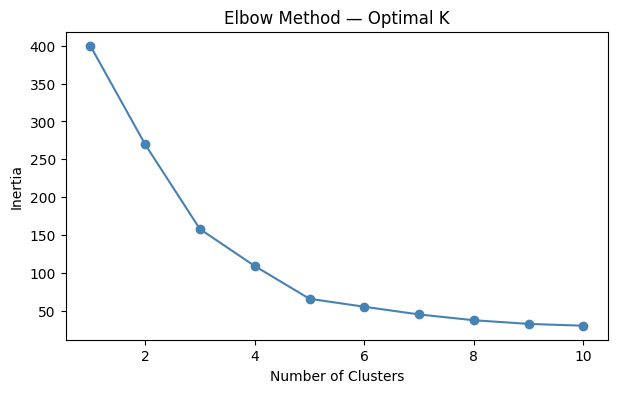

In [15]:
#  CLUSTERING : K-Means
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Select features
X = mall_df[['Annual Income (k$)', 'Spending Score (1-100)']]

# 2. Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Elbow Method — find optimal K
inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(range(1, 11), inertia, marker='o', color='steelblue')
plt.title('Elbow Method — Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

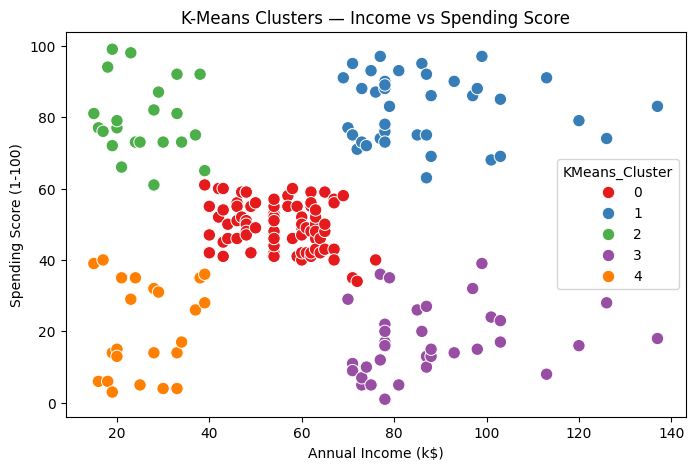

In [16]:
# 4. Train K-Means with optimal K (elbow usually shows 5)
km = KMeans(n_clusters=5, random_state=42, n_init=10)
mall_df['KMeans_Cluster'] = km.fit_predict(X_scaled)

# 5. Visualize
plt.figure(figsize=(8, 5))
sns.scatterplot(data=mall_df, x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='KMeans_Cluster', palette='Set1', s=80)
plt.title('K-Means Clusters — Income vs Spending Score')
plt.show()

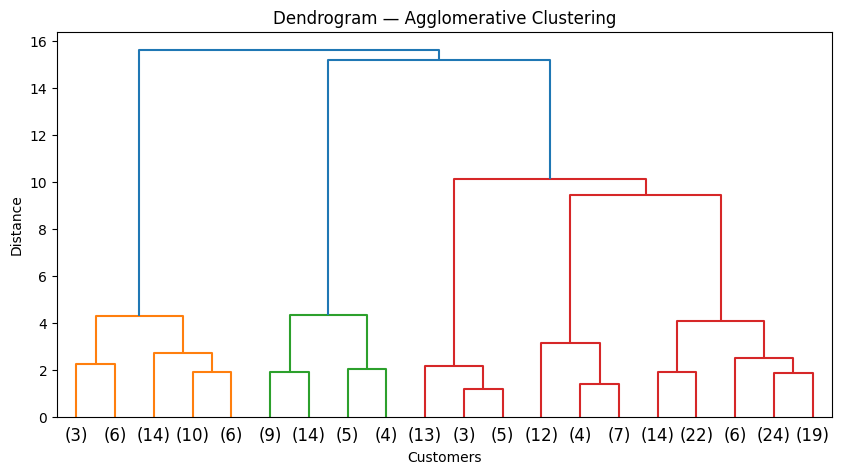

In [17]:
# CLUSTERING : Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# 1. Dendrogram — to find optimal number of clusters
plt.figure(figsize=(10, 5))
linked = linkage(X_scaled, method='ward')
dendrogram(linked, truncate_mode='lastp', p=20)
plt.title('Dendrogram — Agglomerative Clustering')
plt.xlabel('Customers')
plt.ylabel('Distance')
plt.show()

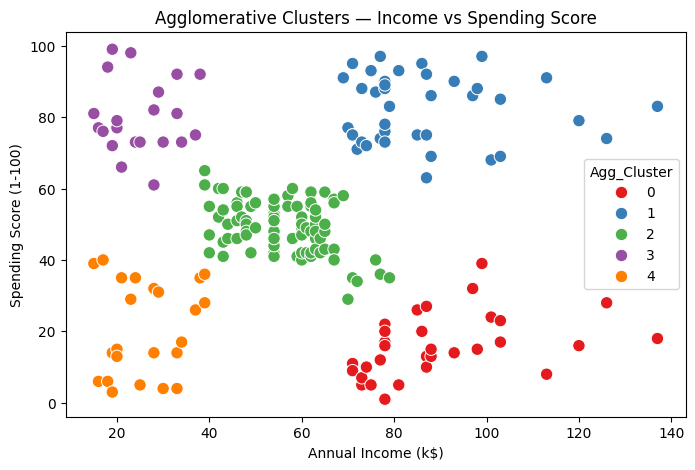

In [18]:
# 2. Train Agglomerative with 5 clusters (same as K-Means for comparison)
agg = AgglomerativeClustering(n_clusters=5)
mall_df['Agg_Cluster'] = agg.fit_predict(X_scaled)

# 3. Visualize
plt.figure(figsize=(8, 5))
sns.scatterplot(data=mall_df, x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Agg_Cluster', palette='Set1', s=80)
plt.title('Agglomerative Clusters — Income vs Spending Score')
plt.show()

Comapring the results of the two algorithms

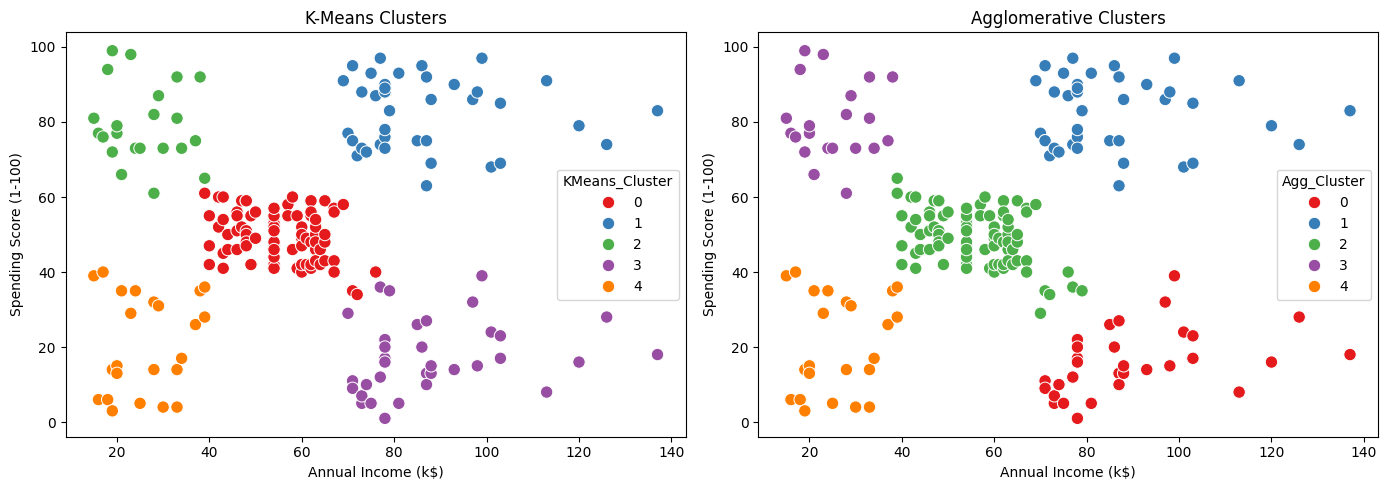

In [19]:
# 4. Compare K-Means vs Agglomerative side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=mall_df, x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='KMeans_Cluster', palette='Set1', ax=axes[0], s=80)
axes[0].set_title('K-Means Clusters')

sns.scatterplot(data=mall_df, x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Agg_Cluster', palette='Set1', ax=axes[1], s=80)
axes[1].set_title('Agglomerative Clusters')

plt.tight_layout()
plt.show()

**Results**
Both K-Means and Agglomerative Clustering identified the same 5 customer segments, confirming that the cluster structure in this dataset is strong and robust. The minor differences in color labeling are just due to how each algorithm numbers its clusters, not actual differences in grouping.


This agreement between two different methods validates our choice of K=5 and gives us confidence in the segments identified.

### Project 2: Credit Card Fraud Detection

In [20]:
# PROJECT 2 : Fraud Detection — EDA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

fraud_df = pd.read_csv('creditcard.csv')

# 1. Shape, dtypes, null check
print("Shape:", fraud_df.shape)
print("\nDtypes:\n", fraud_df.dtypes)
print("\nNull values:\n", fraud_df.isnull().sum())
print("\nPreview:\n", fraud_df.head())

Shape: (284807, 31)

Dtypes:
 Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Null values:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int6

/tmp/ipykernel_532/2637583712.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=fraud_df, palette='Set2')


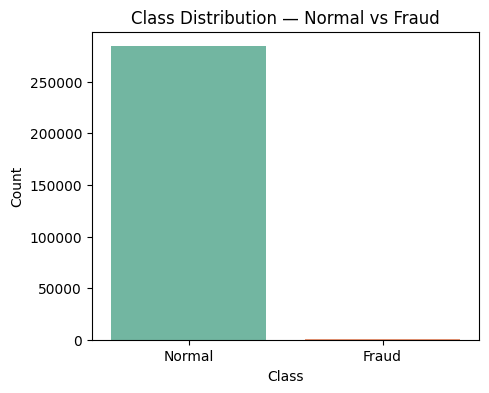

Class counts:
 Class
0    284315
1       492
Name: count, dtype: int64
Fraud percentage: 0.1727%


In [21]:
# 2. Class distribution — fraud vs normal
plt.figure(figsize=(5, 4))
sns.countplot(x='Class', data=fraud_df, palette='Set2')
plt.xticks([0, 1], ['Normal', 'Fraud'])
plt.title('Class Distribution — Normal vs Fraud')
plt.ylabel('Count')
plt.show()

print("Class counts:\n", fraud_df['Class'].value_counts())
print("Fraud percentage: {:.4f}%".format(fraud_df['Class'].mean() * 100))

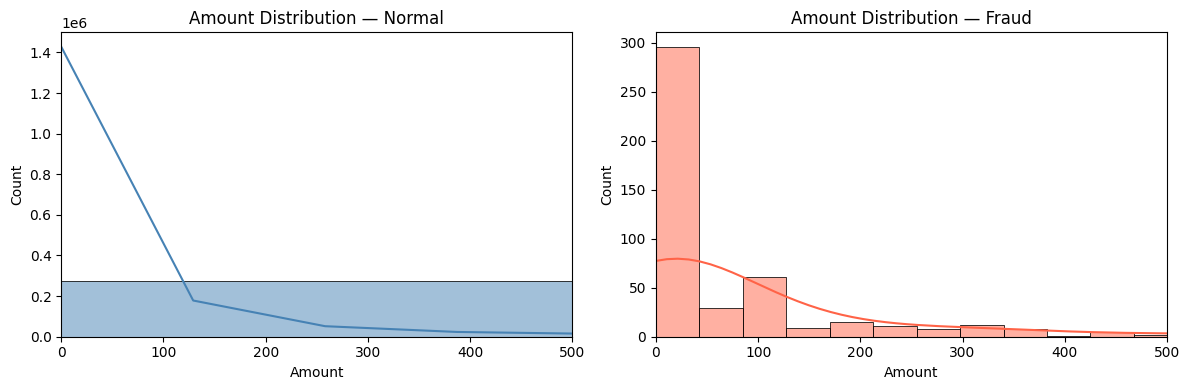

In [22]:
# 3. Transaction Amount distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(fraud_df[fraud_df['Class'] == 0]['Amount'],
             ax=axes[0], kde=True, color='steelblue', bins=50)
axes[0].set_title('Amount Distribution — Normal')
axes[0].set_xlim(0, 500)

sns.histplot(fraud_df[fraud_df['Class'] == 1]['Amount'],
             ax=axes[1], kde=True, color='tomato', bins=50)
axes[1].set_title('Amount Distribution — Fraud')
axes[1].set_xlim(0, 500)

plt.tight_layout()
plt.show()

## 4- AutoML

### 4- AutoML


#### What is AutoML?
AutoML (Automated Machine Learning) automatically handles the tedious steps
of machine learning: choosing the right algorithm, tuning parameters, and
preparing data. Instead of doing everything manually, the machine automatically
searches for the best possible combination.

**Why is it useful?**
- Saves a lot of time
- Accessible to non-experts
- Explores more combinations than a human ever could

---

#### TPOT
TPOT works like natural selection: it generates several pipelines, keeps the
best ones, combines them, and repeats — until it finds the optimal pipeline.

**Advantages:** easy to use, very flexible
**Limits:** slow, consumes a lot of memory

---

#### Auto-sklearn
Auto-sklearn is smarter: it learns from previous results to decide what to
try next, instead of testing everything randomly.

**Advantages:** faster than TPOT, very powerful
**Limits:** difficult to install, works better on Linux

### AutoML om Project 2

In [29]:
# AutoML with TPOT on Project 2
!pip install tpot

In [32]:
from tpot import TPOTClassifier

tpot = TPOTClassifier(
    generations=5,
    population_size=20,
    max_time_mins=10,
    scorers=['f1'],
    random_state=42,
    verbose=2
)

tpot.fit(X_train_sm, y_train_sm)

/usr/local/lib/python3.12/dist-packages/tpot/tpot_estimator/estimator.py:458: UserWarning: Both generations and max_time_mins are set. TPOT will terminate when the first condition is met.
  warnings.warn("Both generations and max_time_mins are set. TPOT will terminate when the first condition is met.")
INFO:distributed.http.proxy:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:36091
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:37757'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:34099 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:34099
INFO:distributed.core:Starting established connection to tcp://127.0.0.1

TPOTClassifier(max_time_mins=10, random_state=42, scorers=['f1'],
               search_space=<tpot.search_spaces.pipelines.sequential.SequentialPipeline object at 0x79c161dd7d40>)

── TPOT AutoML ────────────────────────────────
              precision    recall  f1-score   support

      Normal       1.00      0.91      0.95     56864
       Fraud       0.02      0.93      0.03        98

    accuracy                           0.91     56962
   macro avg       0.51      0.92      0.49     56962
weighted avg       1.00      0.91      0.95     56962



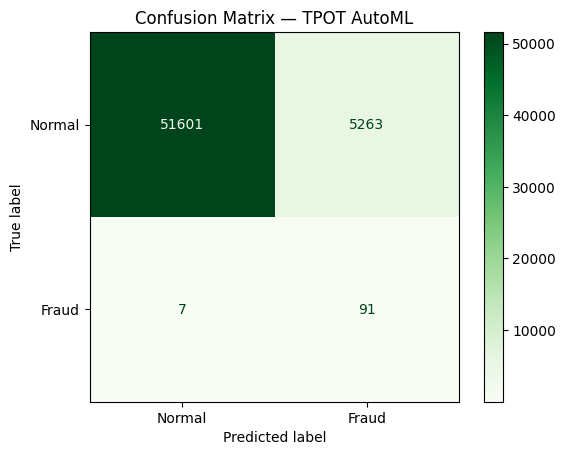

── Best Pipeline found by TPOT ────────────────
Pipeline(steps=[('passthrough', Passthrough()),
                ('selectpercentile',
                 SelectPercentile(percentile=64.0949890237099)),
                ('featureunion-1',
                 FeatureUnion(transformer_list=[('featureunion',
                                                 FeatureUnion(transformer_list=[('powertransformer',
                                                                                 PowerTransformer())])),
                                                ('passthrough',
                                                 Passthrough())])),
                ('featureunion-2',
                 FeatureUnion(transformer_list=[('skiptransformer',
                                                 SkipTransformer()),
                                                ('passthrough',
                                                 Passthrough())])),
                ('decisiontreeclassifier',
                 

In [33]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Predict
y_pred_tpot = tpot.predict(X_test)

# 2. Classification report
print("── TPOT AutoML ────────────────────────────────")
print(classification_report(y_test, y_pred_tpot, target_names=['Normal', 'Fraud']))

# 3. Confusion Matrix
cm_tpot = confusion_matrix(y_test, y_pred_tpot)
disp_tpot = ConfusionMatrixDisplay(confusion_matrix=cm_tpot, display_labels=['Normal', 'Fraud'])
disp_tpot.plot(cmap='Greens')
plt.title('Confusion Matrix — TPOT AutoML')
plt.show()

# 4. Best pipeline TPOT found
print("── Best Pipeline found by TPOT ────────────────")
print(tpot.fitted_pipeline_)

**Concluison**: Manual vs AutoML

TPOT achieved the highest fraud recall (91/98) but at the cost of
5263 false alarms, making it impractical in a real banking system.
XGBoost remains the best overall model, balancing fraud detection
(87/98) with a low false alarm rate (32). AutoML is powerful but
needs careful tuning of its optimization metric in imbalanced datasets.